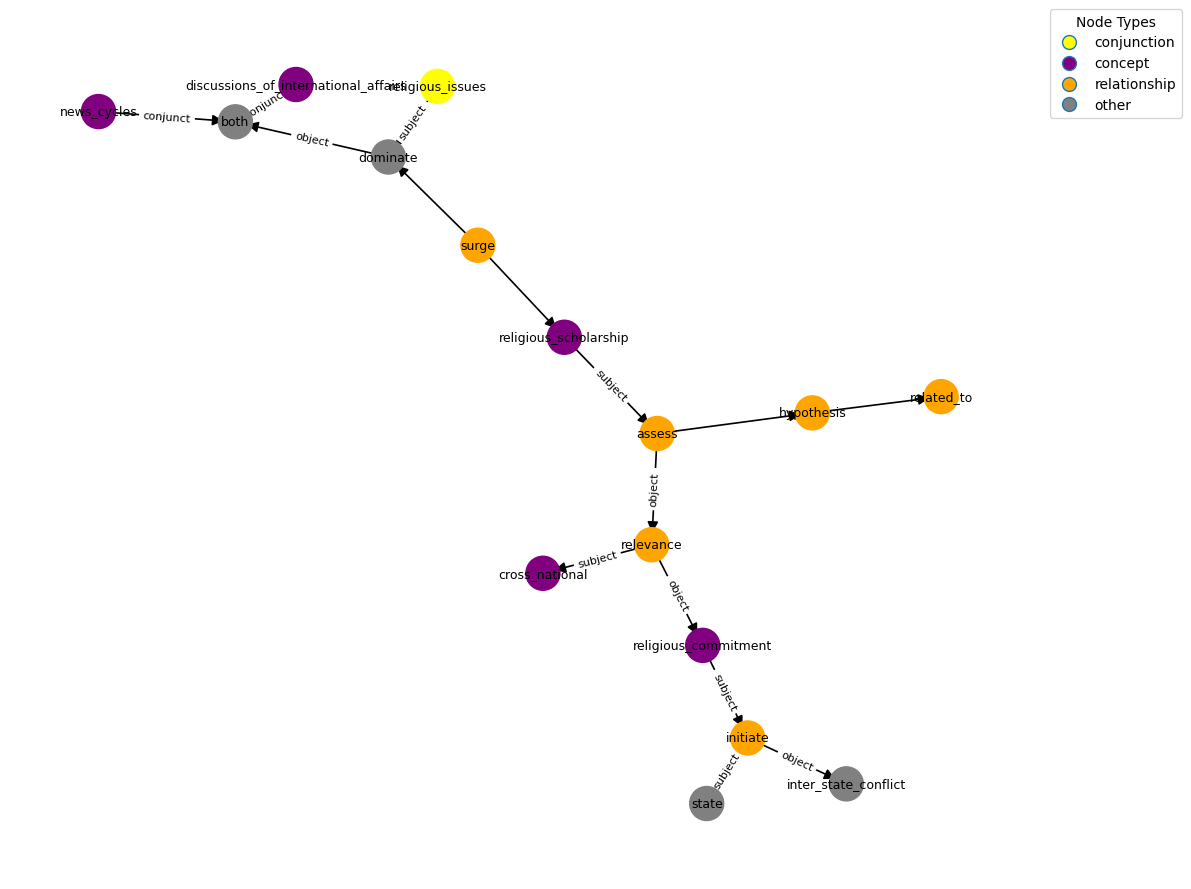

Loaded graph: Graph
Nodes: 16 | Edges: 15
Saved image to: C:\WorldView\worldview\w0rldview\graphML.png


In [6]:
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

# GraphML file path
GRAPHML_PATH = Path(r"C:\WorldView\worldview\w0rldview\test2.graphml")   # Windows
# GRAPHML_PATH = Path("/Users/nick/Documents/my_graph.graphml")    # Mac

NODE_LABEL_ATTR = None
EDGE_LABEL_ATTR = "Edge_Type"
NODE_TYPE_ATTR = "Node_Type"

OUT_IMAGE = Path("graphML.png")

def main():
    if not GRAPHML_PATH.exists():
        raise FileNotFoundError(f"GraphML file not found: {GRAPHML_PATH}")

    G = nx.read_graphml(GRAPHML_PATH)
    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(12, 9))

    # --- Node color by type ---
    node_type_colors = {
        "concept": "purple",
        "people": "blue",
        "location": "green",
        "conjunction": "yellow",
        "relationship": "orange",
        #"subject": "red",
        "target": "red",
        "other": "gray",
    }

    # --- Build node color list ---
    node_colors = []
    for n in G.nodes():
        t = str(G.nodes[n].get(NODE_TYPE_ATTR, "other")).strip().lower()
        node_colors.append(node_type_colors.get(t, node_type_colors["other"]))

    # --- Draw nodes ---
    nx.draw_networkx_nodes(
        G, pos,
        node_size=600,
        node_color=node_colors
    )

    # --- Draw edges with arrowheads ---
    nx.draw_networkx_edges(
        G, pos,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=16,
        width=1.2
    )

    # --- Node labels ---
    if NODE_LABEL_ATTR:
        node_labels = {n: str(G.nodes[n].get(NODE_LABEL_ATTR, n)) for n in G.nodes()}
    else:
        node_labels = {n: str(n) for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=9)

    # --- Edge labels ---
    if EDGE_LABEL_ATTR:
        edge_labels = {}
        if G.is_multigraph():
            for u, v, k, data in G.edges(keys=True, data=True):
                if EDGE_LABEL_ATTR in data:
                    edge_labels[(u, v)] = str(data[EDGE_LABEL_ATTR])
        else:
            for u, v, data in G.edges(data=True):
                if EDGE_LABEL_ATTR in data:
                    edge_labels[(u, v)] = str(data[EDGE_LABEL_ATTR])

        if edge_labels:
            nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    # --- Legend ---
    present_types = []
    for n in G.nodes():
        t = str(G.nodes[n].get(NODE_TYPE_ATTR, "other")).strip().lower()
        if t not in present_types:
            present_types.append(t)

    legend_handles = []
    for t in present_types:
        c = node_type_colors.get(t, node_type_colors["other"])
        legend_handles.append(
            Line2D([0], [0], marker='o', linestyle='',
                   markerfacecolor=c, markersize=10, label=t)
        )

    if legend_handles:
        plt.legend(handles=legend_handles, title="Node Types",
                   loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

    plt.axis("off")
    plt.tight_layout()
    plt.savefig(OUT_IMAGE, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Loaded graph: {G.__class__.__name__}")
    print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")
    print(f"Saved image to: {OUT_IMAGE.resolve()}")

if __name__ == "__main__":
    main()